In [1]:
!git clone https://github.com/YadnikBangale/Shark-tank-India-Decision-Modeling.git

Cloning into 'Shark-tank-India-Decision-Modeling'...
remote: Enumerating objects: 104, done.
remote: Total 104 (delta 0), reused 0 (delta 0), pack-reused 104 (from 1)
Receiving objects: 100% (104/104), 107.35 KiB | 3.46 MiB/s, done.
Resolving deltas: 100% (45/45), done.


In [2]:
import os
os.chdir("Shark-tank-India-Decision-Modeling")

In [3]:
import sys
sys.path.append('./scripts')

In [4]:
from preprocessing_sample import run_preprocessing

In [5]:
import pandas as pd

df = pd.read_csv("Shark Tank India.csv")

X_scaled, y_reg, y_cls, y_shark = run_preprocessing(df)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [6]:
X_scaled['Total Deal Amount'] = y_reg
X_scaled['Accepted Offer'] = y_cls

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style = "whitegrid")

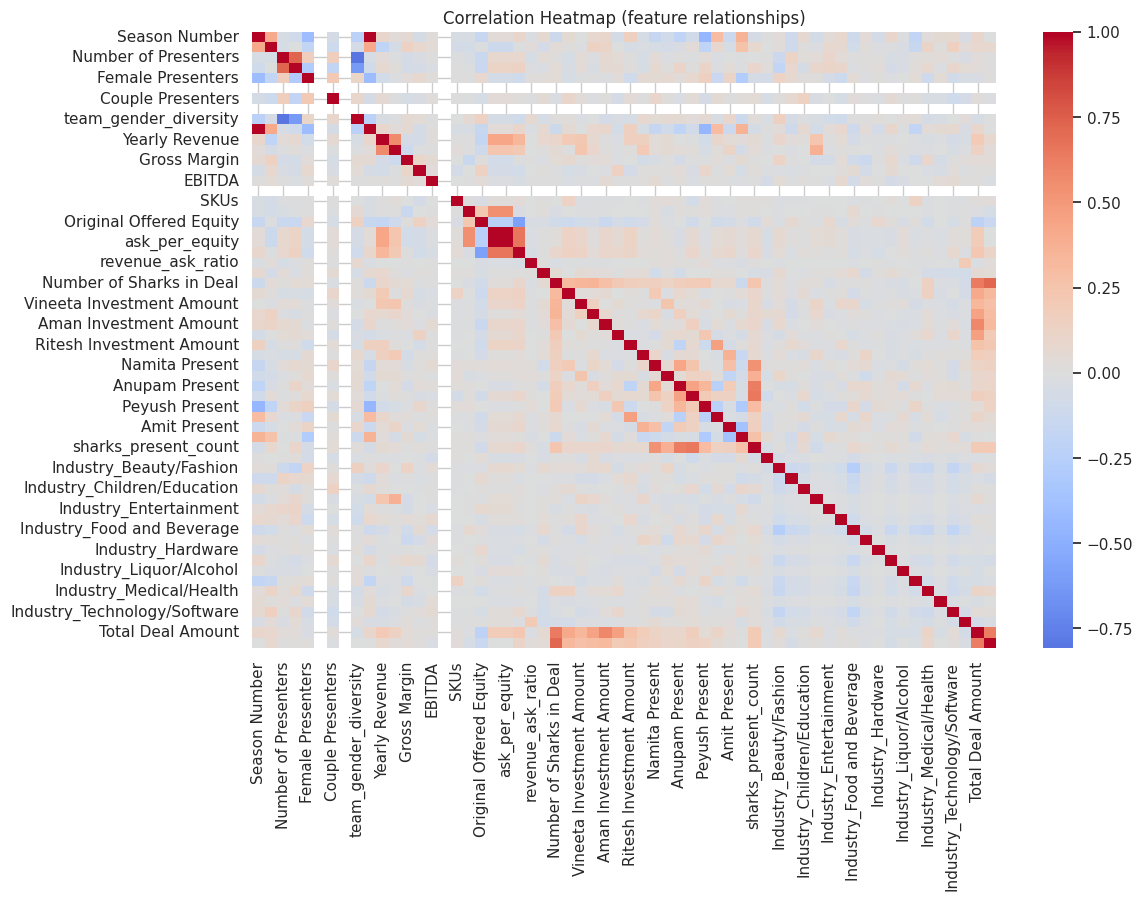

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(X_scaled.corr(), cmap = 'coolwarm', center = 0)
plt.title("Correlation Heatmap (feature relationships)")
plt.show()
## This shows relationships between features and helps identify important predictors.

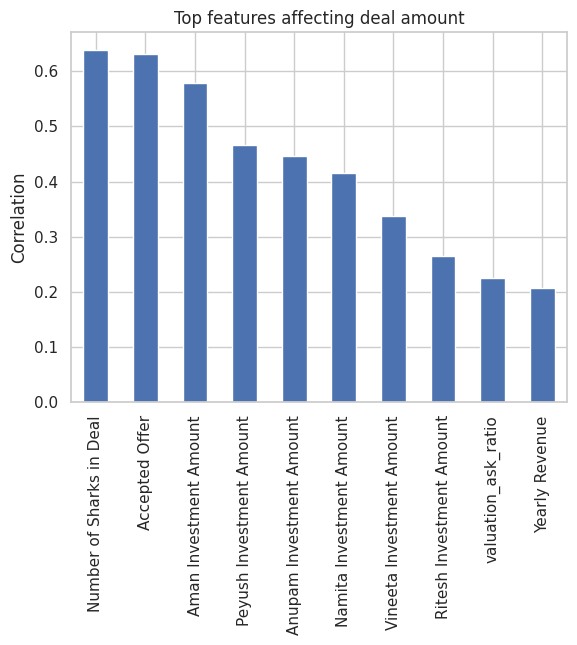

In [9]:
## These features have the strongest influence on investment amount.
corr_target = X_scaled.corr()['Total Deal Amount'].sort_values(ascending = False)
corr_target.drop('Total Deal Amount').head(10).plot(kind='bar')
plt.title('Top features affecting deal amount')
plt.ylabel("Correlation")
plt.show()

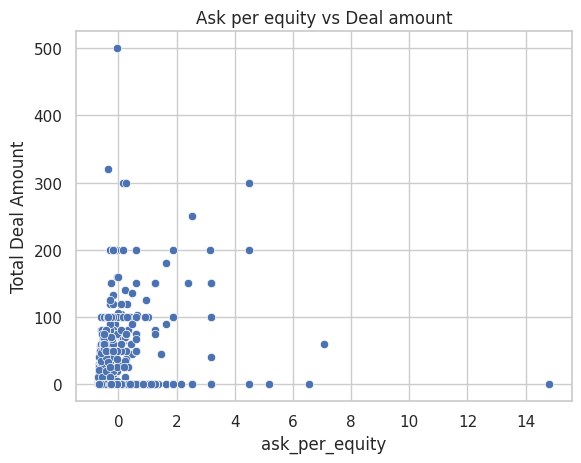

In [10]:
## Higher ask per equity tends to influence deal size
sns.scatterplot(
    x = 'ask_per_equity',
    y = 'Total Deal Amount',
    data = X_scaled
)
plt.title("Ask per equity vs Deal amount")
plt.show()

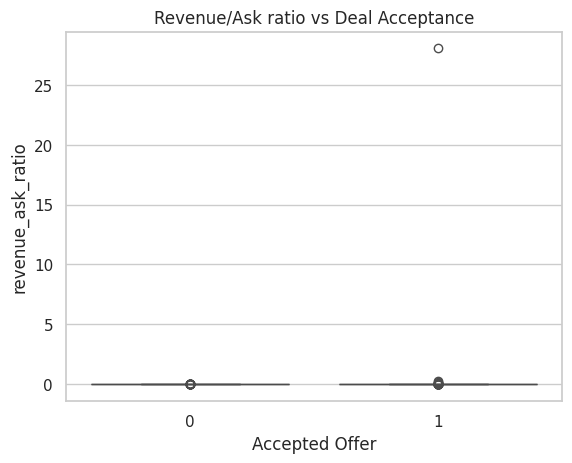

In [11]:
## Higher revenue relative to ask increases chances of acceptance.
sns.boxplot(
    x = 'Accepted Offer',
    y = 'revenue_ask_ratio',
    data = X_scaled
)
plt.title("Revenue/Ask ratio vs Deal Acceptance")
plt.show()

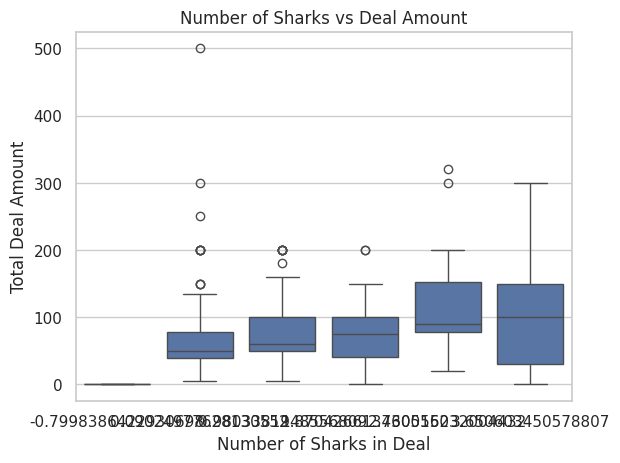

In [12]:
## More sharks generally lead to larger deals.
sns.boxplot(
    x = 'Number of Sharks in Deal',
    y = 'Total Deal Amount',
    data = X_scaled
)
plt.title("Number of Sharks vs Deal Amount")
plt.show()

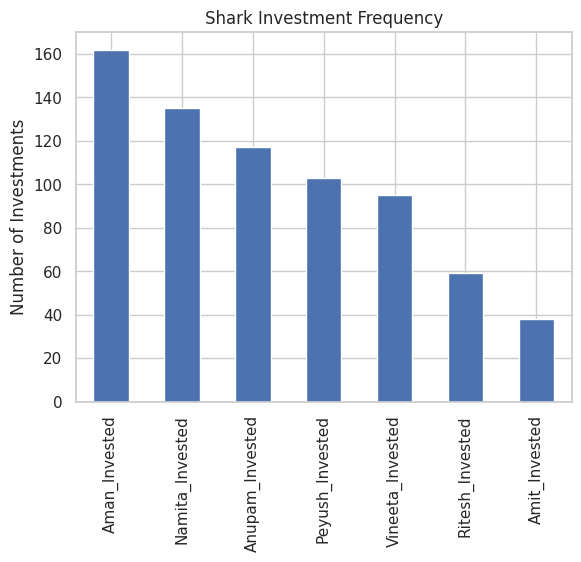

In [14]:
## which shark invests more frequently ?
y_shark.sum().sort_values(ascending = False).plot(kind='bar')
plt.title("Shark Investment Frequency")
plt.ylabel("Number of Investments")
plt.show()

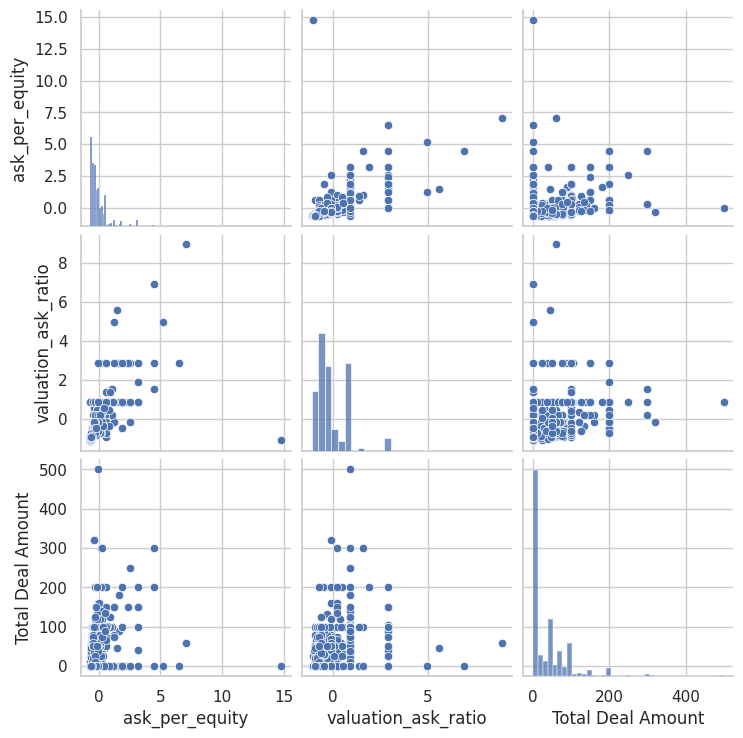

In [15]:
sns.pairplot(X_scaled[['ask_per_equity','valuation_ask_ratio','Total Deal Amount']])
plt.show()